# Image Background Removal Histogram

In [ ]:
10:0:0

In [20]:
import cv2

In [21]:
img = cv2.imread(r"opencv_Images\Screenshot51.png")
img = cv2.resize(img,(500,600))
img2 = cv2.imread(r"opencv_Images\Screenshot24.png")


In [22]:
img_hsv = cv2.cvtColor(img,cv2.COLOR_BGR2HSV)
img2_hsv = cv2.cvtColor(img2 , cv2.COLOR_BGR2HSV)

In [23]:
hist = cv2.calcHist(img2_hsv ,[0,1],None , [180,256],[0,180,0,256])

In [24]:
# mask - m
m = cv2.calcBackProject([img_hsv],[0,1],hist ,[0,180,0,256],1)

In [25]:
res = cv2.bitwise_or(img,img,mask = m)


# kernal 
ker = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))

# reversing the masking
m = cv2.filter2D(m,-1,ker)

In [27]:
# thresholding --> conver image into binary image.
_,thr = cv2.threshold(m ,200,255,cv2.THRESH_BINARY)

# mask to murge all mask
m = cv2.merge((m, m, m))

res = cv2.bitwise_or(img , img ,mask = m)

error: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\core\src\arithm.cpp:230: error: (-215:Assertion failed) (mtype == CV_8U || mtype == CV_8S) && _mask.sameSize(*psrc1) in function 'cv::binary_op'


In [29]:
cv2.imshow("Original image",img)
cv2.imshow("Hsv_img",img_hsv)
cv2.imshow("Image 2",img2)
cv2.imshow("img hsv image",img2_hsv)
cv2.imshow("res",res)
cv2.waitKey(0)
cv2.destroyAllWindows()

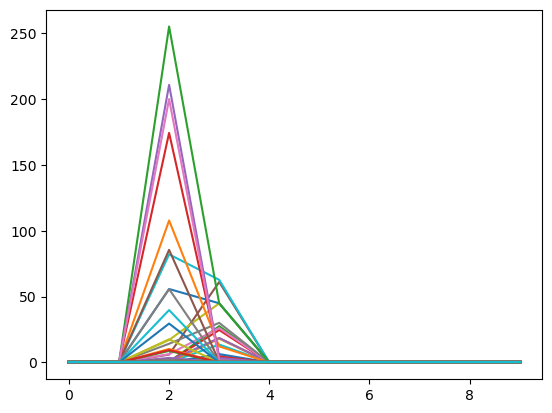

mask created
result crate


In [51]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(r"opencv_Images\img36.1.jpg")
img = cv2.resize(img,(400,500))
img2 = cv2.imread(r"opencv_Images\img36.2.jpg")
img2 = cv2.resize(img2,(400,500))

hsv_img = cv2.cvtColor(img,cv2.COLOR_BGR2HSV)
hsv_img2 = cv2.cvtColor(img2,cv2.COLOR_BGR2HSV)

#  histogram
hist = cv2.calcHist([hsv_img2] ,[0,1] , None , [10,200] ,[0,192,0,256])
# print(hist)

# normalization of hist
cv2.normalize(hist, hist, 0, 255, cv2.NORM_MINMAX)

plt.plot(hist)
plt.show()

# masking
m = cv2.calcBackProject([hsv_img],[0,1],hist ,[0,180,0,256],1)
print("mask created")

# convert probability mask to binary mask.
_, thresh = cv2.threshold(m, 50, 255, cv2.THRESH_BINARY)

# result window
res = cv2.bitwise_and(img , img2 ,mask = thresh)
print("result crate")

cv2.imshow("result",res)
# cv2.imshow("Original image",img)
# cv2.imshow("image 2",img2)
cv2.imshow("Mask",thresh)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [6]:
import cv2
import numpy as np

# ✅ Load both images
img  = cv2.imread(r"opencv_Images\download.jpg")
img2 = cv2.imread(r"opencv_Images\Screenshot24.png")

# ✅ Resize both to same size
img  = cv2.resize(img,  (500, 600))
img2 = cv2.resize(img2, (500, 600))   # FIX 1 — img2 was never resized

# Convert both  to HSV
hsv_img  = cv2.cvtColor(img,  cv2.COLOR_BGR2HSV)
hsv_img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2HSV)

# Build histogram from img2 (the "sample" — what color to look for)
hist = cv2.calcHist([hsv_img2], [0 , 1], None, [180, 256], [0, 180, 0, 256])

# ✅ FIX 2 — Normalize histogram (0 to 255 range)
cv2.normalize(hist, hist, 0, 255, cv2.NORM_MINMAX)

# Back projection — find similar colors in img
m = cv2.calcBackProject([hsv_img], [0, 1], hist, [0, 180, 0, 256], 1)

# ✅ FIX 3 — Apply disc filter to smooth/connect the result
disc = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
cv2.filter2D(m, -1, disc, m)

# ✅ FIX 4 — Threshold to make mask clean (binary)
_, m = cv2.threshold(m, 50, 255, cv2.THRESH_BINARY)

# Apply mask to get result
res = cv2.bitwise_and(img, img, mask=m)   # FIX 5 — use bitwise_and not bitwise_or

cv2.imshow("Original image", img)
cv2.imshow("Sample image (img2)", img2)
cv2.imshow("Back Projection Mask", m)
cv2.imshow("Result", res)
cv2.waitKey(0)
cv2.destroyAllWindows()
# ```

# ---

## All Fixes Explained

# | # | Problem | Fix |
# |---|---------|-----|
# | 1 | `img2` never resized | Added `cv2.resize(img2, (500,600))` |
# | 2 | Histogram not normalized → all values near 0 → blank mask | Added `cv2.normalize(hist, ...)` |
# | 3 | Back projection result is noisy/scattered | Added `disc filter` + `filter2D` |
# | 4 | Mask has very low values, not binary | Added `cv2.threshold(m, 50, 255, ...)` |
# | 5 | `bitwise_or` shows everything, use `bitwise_and` with mask | Changed to `bitwise_and` |

# ---

# ## Back Projection Flow
# ```
# img2 (sample)
#      ↓
#  calcHist()        → "what colors exist in img2?"
#      ↓
#  normalize()       → scale to 0-255
#      ↓
#  calcBackProject() → "where do those colors appear in img?"
#      ↓
#  filter2D()        → smooth the result
#      ↓
#  threshold()       → make it clean black/white mask
#      ↓
#  bitwise_and()     → apply mask → final result ✅

In [30]:
import cv2

img = cv2.imread(r"opencv_Images\img36.1.jpg")
img = cv2.resize(img, (400, 500))
img2 = cv2.imread(r"opencv_Images\img36.2.jpg")
img2 = cv2.resize(img2, (400, 500))

hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
hsv_img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2HSV)

hist = cv2.calcHist([hsv_img2], [0, 1], None, [180, 256], [0, 180, 0, 256])
cv2.normalize(hist, hist, 0, 255, cv2.NORM_MINMAX)

m = cv2.calcBackProject([hsv_img], [0, 1], hist, [0, 180, 0, 256], 1)

_, thresh = cv2.threshold(m, 50, 255, cv2.THRESH_BINARY)

# ✅ Clean up the mask
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=3)
thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
thresh = cv2.dilate(thresh, kernel, iterations=2)

res = cv2.bitwise_and(img2, img2, mask=thresh)

cv2.imshow("Result", res)
cv2.imshow("Original image", img)
cv2.imshow("image 2", img2)
cv2.waitKey(0)
cv2.destroyAllWindows()


# final result

In [36]:
import cv2
import matplotlib.pyplot as plt

img1 = cv2.imread(r"opencv_Images\pictures\apple.jpg")
img1 = cv2.resize(img1,(900,700))
img2 = cv2.imread(r"opencv_Images\pictures\apple_background.jpg")
img2 = cv2.resize(img2,(600,500))

# in doing some changes in an image we do changes in hsv image.
hsv1 = cv2.cvtColor(img1, cv2.COLOR_BGR2HSV)
hsv2 = cv2.cvtColor(img2,cv2.COLOR_BGR2HSV)

# creating histogram
hist = cv2.calcHist([hsv2] ,[0,1] , None ,[180,256] ,[0,180,0,256])
mask = cv2.calcBackProject([hsv1] ,[0,1],hist ,[0,180,0,256] ,1)

# plt.plot(hist)
# plt.show()

# result
# res = cv2.bitwise_or(img1 , img1 , mask = mask)

# kernel
ker = cv2.getStructuringElement(cv2.MORPH_ELLIPSE , (4,4))
mask = cv2.filter2D(mask , -1 , ker)

# thresholding - convert image into binary image so we can use the image wherever we wat
_,th = cv2.threshold(mask , 250, 255, cv2.THRESH_BINARY)
mask = cv2.merge((mask,mask,mask))

res = cv2.bitwise_or(img1,mask)

# cv2.imshow("Image",img1)
# cv2.imshow("image2",img2)
cv2.imshow("result",res)
# cv2.imshow("hsv image 1",hsv1)
# cv2.imshow("hsv image 2",hsv2)
cv2.waitKey(0)
cv2.destroyAllWindows()